# Data Analysis on Power Plants Around the Globe: Exploring Capacity, Fuel Type, Generation and Geographic Patterns

---

## Abstract

The Global Power Plant Database is an, open-source dataset that records information about power plants across the world, including location, capacity, fuel type and annual electricity generation. For this report, Jupyter Notebook will be used to perform data cleaning, exploration and analysis on the dataset.

The analysis begins with loading and inspecting the raw data, summarising its structure, and identifying key variables of interest. After that, performing systematic data cleaning, including dropping irrelevant columns, handling missing values and checking for duplicate rows, etc.

Next, summary statistics, distribution plots, outlier analysis, and correlation analysis are created. Relationships between capacity, electricity generation, commissioned year and fuel type, and how they vary across countries, are then explored. Three research questions are proposed and answered using the exploration and analysis carried out:


**1. How do the types of fuel used affect the capacity of a power plant ?**

**2. How does the capacity of a power plant affect the amount of electricity it generates ?**

**3. Is there a geographical pattern to the distribution of high capacity power plants ?**

The report concludes with findings and reflections on the analytical process.


## Introduction

The Global Power Plant Dataset provides a list of power plants across many countries from all around the world, their fuel types and technologies. Each plant has attributes such as installed capacity, primary fuel, geographical coordinates and annual electricity generation.

The aim of this report is to demonstrate a full data analysis process in Python, starting from a CSV file and ending with a structured analysis. The main objectives are:

- To load, inspect and understand the dataset.  
- To clean and wrangle the data, incluing handling missing values, dropping redundant columns and creating new columns where appropriate.  
- To perform exploratory data analysis, including numerical summaries, visualisations, etc.  
- To answer the three research questions that were created based on this dataset.


## Dataset Overview

The dataset used in this report contains around 35,000 rows, where each row represents a single power plant. The dataset includes 36 columns in the raw form. These columns fall into several categories:

- **Identifying fields:**  
  - name: the name of the power plant.  
  - gppd_idnr: a unique ID for each plant, used as a primary key.  
  - wepp_id: an alternative ID.

- **Geographical information:**  
  - country and country_long: A 3-letter country code and full country name.  
  - latitude and longitude: coordinates of each plant.  
  - geolocation_source: the source of the location information.

- **Technical and descriptive attributes:**  
  - capacity_mw: electrical generating capacity of the plants in megawatts.  
  - primary_fuel and other_fuel1 - other_fuel3: the main fuel and any additional fuels.  
  - commissioning_year: year the plant was commissioned.  
  - owner and source: information about the plant owners and the data source.  
  - url: a link to the original data source.

- **Generation-related fields:**  
  - generation_gwh_2013 - generation_gwh_2019: reported amount of electricity generated in GWh for each year.  
  - estimated_generation_gwh_2013 - estimated_generation_gwh_2017: estimated generation for each year.  
  - estimated_generation_note_2013 - estimated_generation_note_2017: text fields describing the method used for estimation.  
  - generation_data_source: attribution for the reported generation information.  
  - year_of_capacity_data: the year from which the capacity information originates.

From the missing value summary, it can be seen that:

- Some columns such as country, name, gppd_idnr, capacity_mw, latitude, longitude and primary_fuel have no missing values, making them suitable for use as core variables.
- Other columns, such as other_fuel1, other_fuel2, other_fuel3, owner, many of the generation fields, and wepp_id, have high proportions of missing values.


### Load libraries, dataset, check first rows, shape and column names

In [ ]:
# Load dataset
import pandas as pd

df = pd.read_csv("/content/global_power_plant_database.csv")

/tmp/ipykernel_2837/2910641701.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/global_power_plant_database.csv")


In [ ]:
# check first few rows
df.head()

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [ ]:
# check the shape of the dataset
df.shape

(34936, 36)

In [ ]:
# check column names
df.columns

Index(['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw',
       'latitude', 'longitude', 'primary_fuel', 'other_fuel1', 'other_fuel2',
       'other_fuel3', 'commissioning_year', 'owner', 'source', 'url',
       'geolocation_source', 'wepp_id', 'year_of_capacity_data',
       'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015',
       'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018',
       'generation_gwh_2019', 'generation_data_source',
       'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014',
       'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016',
       'estimated_generation_gwh_2017', 'estimated_generation_note_2013',
       'estimated_generation_note_2014', 'estimated_generation_note_2015',
       'estimated_generation_note_2016', 'estimated_generation_note_2017'],
      dtype='object')

In [ ]:
# SUMMARY OF DATASET

# Data types
print("\nData types:")
print(df.dtypes)

# Number of unique values per column
print("\nUnique values per column:")
print(df.nunique())

# Missing values per column
print("\nMissing values per column:")
print(df.isna().sum())


Data types:
country                            object
country_long                       object
name                               object
gppd_idnr                          object
capacity_mw                       float64
latitude                          float64
longitude                         float64
primary_fuel                       object
other_fuel1                        object
other_fuel2                        object
other_fuel3                        object
commissioning_year                float64
owner                              object
source                             object
url                                object
geolocation_source                 object
wepp_id                            object
year_of_capacity_data             float64
generation_gwh_2013               float64
generation_gwh_2014               float64
generation_gwh_2015               float64
generation_gwh_2016               float64
generation_gwh_2017               float64
generation_gwh_2018  

In [ ]:
# more information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  object 
 1   country_long                    34936 non-null  object 
 2   name                            34936 non-null  object 
 3   gppd_idnr                       34936 non-null  object 
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  object 
 8   other_fuel1                     1944 non-null   object 
 9   other_fuel2                     276 non-null    object 
 10  other_fuel3                     92 non-null     object 
 11  commissioning_year              17447 non-null  float64
 12  owner                           

In [ ]:
# show unique values for all columns
columns = df.columns.to_list()

for col in columns:
  print(col, ":")
  print(df[col].unique())
  print()

country :
['AFG' 'ALB' 'DZA' 'AGO' 'ATA' 'ARG' 'ARM' 'AUS' 'AUT' 'AZE' 'BHR' 'BGD'
 'BLR' 'BEL' 'BEN' 'BTN' 'BOL' 'BIH' 'BWA' 'BRA' 'BRN' 'BGR' 'BFA' 'BDI'
 'KHM' 'CMR' 'CAN' 'CPV' 'CAF' 'CHL' 'CHN' 'COL' 'COG' 'CRI' 'CIV' 'HRV'
 'CUB' 'CYP' 'CZE' 'COD' 'DNK' 'DJI' 'DOM' 'ECU' 'EGY' 'SLV' 'GNQ' 'ERI'
 'EST' 'ETH' 'FJI' 'FIN' 'FRA' 'GUF' 'GAB' 'GMB' 'GEO' 'DEU' 'GHA' 'GRC'
 'GTM' 'GIN' 'GNB' 'GUY' 'HND' 'HUN' 'ISL' 'IND' 'IDN' 'IRN' 'IRQ' 'IRL'
 'ISR' 'ITA' 'JAM' 'JPN' 'JOR' 'KAZ' 'KEN' 'KOS' 'KWT' 'KGZ' 'LAO' 'LVA'
 'LBN' 'LSO' 'LBR' 'LBY' 'LTU' 'LUX' 'MKD' 'MDG' 'MWI' 'MYS' 'MLI' 'MRT'
 'MUS' 'MEX' 'MDA' 'MNG' 'MNE' 'MAR' 'MOZ' 'MMR' 'NAM' 'NPL' 'NLD' 'NZL'
 'NIC' 'NER' 'NGA' 'PRK' 'NOR' 'OMN' 'PAK' 'PSE' 'PAN' 'PNG' 'PRY' 'PER'
 'PHL' 'POL' 'PRT' 'QAT' 'ROU' 'RUS' 'RWA' 'LCA' 'SAU' 'SEN' 'SRB' 'SLE'
 'SGP' 'SVK' 'SVN' 'ZAF' 'KOR' 'ESP' 'LKA' 'SDN' 'SUR' 'SWZ' 'SWE' 'CHE'
 'SYR' 'TWN' 'TJK' 'TZA' 'THA' 'TGO' 'TTO' 'TUN' 'TUR' 'TKM' 'UGA' 'UKR'
 'ARE' 'GBR' 'USA' 'URY' 'UZB' 'VEN' 'VNM

### Summary and findings

From the data type summary, the dataset contains 36 columns, with a mix of 19 object (string/categorical) fields and 17 numeric (float) fields. Core fields include the country, country_long, name, gppd_idnr, capacity_mw, latitude, longitude and primary_fuel fields. They are fully populated with no missing values, which makes them reliable selections for analysis and for describing each power plant. In comparison, some descriptive fields such as the owner, wepp_id, and the additional fuel fields, other_fuel1-3 are missing large amounts of data, with over 90% missing values in the latter, suggesting that most plants only have a single recorded primary fuel.

The unique value counts highlight the scale and diversity of the dataset: there are power plants in 167 countries, over 34,000 unique plant names, and more than 5,600 different capacity values. The primary_fuel column is relatively well-structured with 15 fuel categories, while fields like source and geolocation_source have hundreds of different data providers. For electricity generation, the actual generation_gwh_20XX columns are very incomplete with only around 6,000-9,600 non-null values for each year. However, the estimated_generation_gwh columns are much more populated by comparison. The estimated_generation_note fields only have a few unique labels, such as HYDRO-V1, WIND-V1, SOLAR-V1, SOLAR-V1-NO-AGE, NO-ESTIMATION, which describe the estimation method used.

In [ ]:
# show percentage of missing data for each column
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_percentage': missing_percentage.round(2)
})

print(missing_df)


                                missing_count  missing_percentage
other_fuel3                             34844               99.74
other_fuel2                             34660               99.21
other_fuel1                             32992               94.44
generation_gwh_2013                     28519               81.63
generation_gwh_2014                     27710               79.32
generation_gwh_2015                     26733               76.52
generation_gwh_2016                     25792               73.83
generation_gwh_2017                     25436               72.81
generation_gwh_2018                     25299               72.42
generation_gwh_2019                     25277               72.35
generation_data_source                  23536               67.37
year_of_capacity_data                   20049               57.39
estimated_generation_gwh_2013           18816               53.86
wepp_id                                 18702               53.53
estimated_

## Data Cleaning and Wrangling

The action carried out in this section include:

1. Column selection and dropping unwanted columns.  
2. Handling missing values.
3. Checking for duplicates.  
4. Ensuring correct data types.  
5. Standardising selected text columns (if applicable).
6. Creating new derived columns (if applicable).

### Variable selection and column dropping
#### SELECTED COLUMNS

Based on the dataset overview and missing value analysis, The records selected for further analysis are:

1. country
2. name
3. gppd_idnr
4. capacity_mw
5. latitude
6. longitude
7. primary_fuel
8. commissioning_year
9. source
10. geolocation source
11. year_of_capacity_data
12. generation_gwh_2013
13. generation_gwh_2014
14. generation_gwh_2015
15. generation_gwh_2016
16. generation_gwh_2017
17. generation_gwh_2018
18. generation_gwh_2019
19. estimated_generation_gwh_2013
20. estimated_generation_gwh_2014
21. estimated_generation_gwh_2015
22. estimated_generation_gwh_2016
23. estimated_generation_gwh_2017



#### DROPPED COLUMNS AND REASON(S) THEY WERE DROPPED
A total of 13 rows were dropped.

1. country_long: This column was dropped because there was an alternative in the form of the country column

2. other_fuel (1,2 and 3): These columns were dropped because they have extremely high amounts of missing data, signifying that most power plants only have one major fuel for power generation.

3. url: The urls to the webpages were the data was sourced from. This was removed as it has no value when it comes to data analysis. The source column is better for defining the data sources.

4. wepp_id: This is an identifier for each power plant. However, it has multiple duplicates, which defeats the purpose of unique identification. Also, the gppd_idnr column, serves as a suitable alternative for identifying each plant and has no duplicates.

5. owner: This column has a high degree of missing data, and unlike numeric fields or some other text fields which can be inferred, the owner(s) of a power plant cannot easily be inferred as there can be multiple such organizations within a country.

6. generation_data_source: This column was removed, because it will become redundant once the actual and estimated values for power generated in years 2013-2017 are merged.

7. estimated_generation_notes (2013-2017): These columns were dropped, because they will no longer have any value, once the actual ad estimated values for power generated in years 2013-2017 are merged.


The code to drop the specified columns can be seen below:

In [ ]:
# Dropping unwanted columns

df = df.drop(columns=[
    "country_long",
    "other_fuel1",
    "other_fuel2",
    "other_fuel3",
    "url",
    "wepp_id",
    "owner",
    "generation_data_source",
    "estimated_generation_note_2013",
    "estimated_generation_note_2014",
    "estimated_generation_note_2015",
    "estimated_generation_note_2016",
    "estimated_generation_note_2017",
])

In [ ]:
# check dataframe

df.shape

(34936, 23)

### Handling missing values

Here code will be provided to handle missing values across the remaining columns, and reasons for the methods used will also be provided.

In [ ]:
# for vital columns, where missing values cannot be inferred rows with missing data will be dropped
vital_columns = ["country", "name", "capacity_mw", "latitude", "longitude", "primary_fuel"]

print("Total rows missing data in important fields:")
print(df[vital_columns].isna().sum())

df = df.dropna(subset=vital_columns)

print("Check again for missing values in important fields:")
print(df[vital_columns].isna().sum())

Total rows missing data in important fields:
country         0
name            0
capacity_mw     0
latitude        0
longitude       0
primary_fuel    0
dtype: int64
Check again for missing values in important fields:
country         0
name            0
capacity_mw     0
latitude        0
longitude       0
primary_fuel    0
dtype: int64


In [ ]:
# for fields like the source and geolocation source, let missing values become a new "Unknown source" category

df["source"] = df["source"].fillna("Unknown")
df["geolocation_source"] = df["geolocation_source"].fillna("Unknown")

# check again for empty data
print(df["source"].isna().sum())
print(df["geolocation_source"].isna().sum())

0
0


#### Justification for creating unknown category

Missing values in these fields do not affect any numerical operations, and they also serve to show that a data source was not available for those specific plants, which can be said to be somewhat valuable information.

In [ ]:
# for date/time columns like commissioning year and year of capacity data, their median and modes will be used fill in missing data

# As seen above, the two columns are already float64 types, therefore, there is no need to convert

# get median for commission year
commission_median = df["commissioning_year"].median(skipna=True)

# fill missing values with median
df["commissioning_year"] = df["commissioning_year"].fillna(commission_median)

# get mode for year of capacity
year_cap_mode = df["year_of_capacity_data"].mode(dropna=True)[0]

# fill missing values with mode
df["year_of_capacity_data"] = df["year_of_capacity_data"].fillna(year_cap_mode)


# check again for empty data
print(df["commissioning_year"].isna().sum())
print(df["year_of_capacity_data"].isna().sum())


0
0


#### Justification for use of median and mode

Median is a common option for filling in missing data, when mean, mode or interpolation is not viable. since the commissioning_year column deals with years, it is not possible to use the average year. This is the same for interpolation. Mode cannot be used because it is very unlikely for multiple plants to be commissioned within the same year even across the world.

Mode was used to fill in the missing values for the year_of_capacity_data column, because once again, mean and interpolation are not viable, and compared to median, there is a much higher chance data was gathered in bulk within specific periods of time.

In [ ]:
import numpy as np


years_estimated = [2013, 2014, 2015, 2016, 2017]
years_all = [2013, 2014, 2015, 2016, 2017, 2018, 2019]


for y in years_all:
    reported_col = f"generation_gwh_{y}"
    est_col = f"estimated_generation_gwh_{y}"
    final_col = f"final_generation_gwh_{y}"

    if reported_col not in df.columns:
        continue

    # start with reported values
    df[final_col] = df[reported_col]

    # fill missing values with estimated value if available
    if est_col in df.columns:
        df[final_col] = df[final_col].fillna(df[est_col])



final_gen_cols = [
    "final_generation_gwh_2013",
    "final_generation_gwh_2014",
    "final_generation_gwh_2015",
    "final_generation_gwh_2016",
    "final_generation_gwh_2017",
    "final_generation_gwh_2018",
    "final_generation_gwh_2019",
]

if final_gen_cols:

    # Interpolate across years for each plant
    df[final_gen_cols] = df[final_gen_cols].T.interpolate(limit_direction="both").T

    # check for rows where all year values are still NaN
    all_nan_rows = df[final_gen_cols].isna().all(axis=1)
    print("Rows with all years missing final generation values after interpolation:", all_nan_rows.sum())


Rows with all years missing final generation values after interpolation: 1466


In [ ]:
all_nan_rows = df[final_gen_cols].isna().all(axis=1)

df = df[~all_nan_rows]

df.shape

(33470, 30)

In [ ]:
# drop columns used to create final values
columns_to_drop = [
    "generation_gwh_2013",
    "generation_gwh_2014",
    "generation_gwh_2015",
    "generation_gwh_2016",
    "generation_gwh_2017",
    "generation_gwh_2018",
    "generation_gwh_2019",
    "estimated_generation_gwh_2013",
    "estimated_generation_gwh_2014",
    "estimated_generation_gwh_2015",
    "estimated_generation_gwh_2016",
    "estimated_generation_gwh_2017"
]

df = df.drop(columns=columns_to_drop)


In [ ]:
df.shape

(33470, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33470 entries, 0 to 34935
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    33470 non-null  object 
 1   name                       33470 non-null  object 
 2   gppd_idnr                  33470 non-null  object 
 3   capacity_mw                33470 non-null  float64
 4   latitude                   33470 non-null  float64
 5   longitude                  33470 non-null  float64
 6   primary_fuel               33470 non-null  object 
 7   commissioning_year         33470 non-null  float64
 8   source                     33470 non-null  object 
 9   geolocation_source         33470 non-null  object 
 10  year_of_capacity_data      33470 non-null  float64
 11  final_generation_gwh_2013  33470 non-null  float64
 12  final_generation_gwh_2014  33470 non-null  float64
 13  final_generation_gwh_2015  33470 non-null  float64


#### Justification for substituting with estimated values and interpolation

The electricity generation data in the dataset is split across two separate sources: actual values (generation_gwh_2013 - generation_gwh_2019) and estimated values(estimated_generation_gwh_2013 - estimated_generation_gwh_2017).

From the data summary, many plants have either actual or estimated values for a given year and both aren't available at the same time, which would make it difficult to analyse annual generation if these fields were kept separate. Creating unified columns allows each year's generation to be represented in a single variable, using the most reliable information available.

The substitution rule that was used is: where actual generation is present, it is used and where it is missing, the estimated value is used instead. This ensures that real measurements are always prioritised, while still making use of the additional information provided by the estimation process instead of discarding it. The estimation notes indicate that a standardised modelling approach was used, which makes these estimates more defensible than random imputations.

After combining actual and estimated values, there are still gaps in the data for individual plants. In these cases, linear interpolation is applied across the final_generation_gwh columns within each plant. This approach is justified because annual generation amount for electricity typically changes gradually from year to year, especially for large plants, so intermediate values can be reasonably approximated from neighbouring years. Interpolation is only used where there is information on both sides of a missing value; it is not used in cases where the necessary data is not available. Plants that still have all years missing after this process are dropped from the analysis, as there is no other way to get reliable values to fill in.

In [ ]:
# Check for duplicates

duplicate_count = df.duplicated().sum()
print("Duplicate rows found:", duplicate_count)

Duplicate rows found: 0


In [ ]:
# classify columns for future actions

string_columns = [
    "country",
    "name",
    "gppd_idnr",
    "primary_fuel",
    "source",
    "geolocation_source",
]

numerical_columns = [
    "capacity_mw",
    "latitude",
    "longitude",
    "commissioning_year",
    "year_of_capacity_data",
    "final_generation_gwh_2013",
    "final_generation_gwh_2014",
    "final_generation_gwh_2015",
    "final_generation_gwh_2016",
    "final_generation_gwh_2017",
    "final_generation_gwh_2018",
    "final_generation_gwh_2019",
]

In [ ]:
# check string columns for all unique values to find those that need to be standardized

for col in string_columns:
  print(col, ":")
  print(df[col].unique())
  print()

country :
['AFG' 'ALB' 'DZA' 'AGO' 'ARG' 'ARM' 'AUS' 'AUT' 'AZE' 'BHR' 'BGD' 'BLR'
 'BEL' 'BEN' 'BTN' 'BOL' 'BIH' 'BWA' 'BRA' 'BRN' 'BGR' 'BFA' 'BDI' 'KHM'
 'CMR' 'CAN' 'CPV' 'CAF' 'CHL' 'CHN' 'COL' 'COG' 'CRI' 'CIV' 'HRV' 'CUB'
 'CYP' 'CZE' 'COD' 'DNK' 'DOM' 'ECU' 'EGY' 'SLV' 'GNQ' 'ERI' 'EST' 'ETH'
 'FJI' 'FIN' 'FRA' 'GUF' 'GAB' 'GEO' 'DEU' 'GHA' 'GRC' 'GTM' 'GIN' 'HND'
 'HUN' 'ISL' 'IND' 'IDN' 'IRN' 'IRQ' 'IRL' 'ISR' 'ITA' 'JAM' 'JPN' 'JOR'
 'KAZ' 'KEN' 'KWT' 'KGZ' 'LAO' 'LVA' 'LBN' 'LSO' 'LBR' 'LBY' 'LTU' 'LUX'
 'MKD' 'MDG' 'MWI' 'MYS' 'MLI' 'MRT' 'MUS' 'MEX' 'MDA' 'MNG' 'MNE' 'MAR'
 'MOZ' 'MMR' 'NAM' 'NPL' 'NLD' 'NZL' 'NIC' 'NER' 'NGA' 'PRK' 'NOR' 'OMN'
 'PAK' 'PSE' 'PAN' 'PNG' 'PRY' 'PER' 'PHL' 'POL' 'PRT' 'QAT' 'ROU' 'RUS'
 'RWA' 'LCA' 'SAU' 'SEN' 'SRB' 'SLE' 'SGP' 'SVK' 'SVN' 'ZAF' 'KOR' 'ESP'
 'LKA' 'SDN' 'SUR' 'SWZ' 'SWE' 'CHE' 'SYR' 'TWN' 'TJK' 'TZA' 'THA' 'TGO'
 'TTO' 'TUN' 'TUR' 'TKM' 'UGA' 'UKR' 'ARE' 'GBR' 'USA' 'URY' 'UZB' 'VEN'
 'VNM' 'YEM' 'ZMB' 'ZWE']

name :
['Kajak

## Data Exploration

In [ ]:
# generate statistics summary for numeric columns
numeric_summary = df[numerical_columns].agg(["mean", "median", "min", "max", "std"]).T

print(numeric_summary)

                                  mean      median        min         max  \
capacity_mw                 168.661949    17.78150     1.0000  22500.0000   
latitude                     33.418409    39.76255   -53.7862     71.2920   
longitude                    -6.493776    -1.87455  -179.1338    178.0498   
commissioning_year         2002.063173  2007.00000  1896.0000   2020.0000   
year_of_capacity_data      2018.702330  2019.00000  2000.0000   2019.0000   
final_generation_gwh_2013   669.385074    32.19500  -947.6000  82810.7700   
final_generation_gwh_2014   669.634651    32.63000  -989.6190  82810.7700   
final_generation_gwh_2015   672.997636    32.71000  -864.4280  82810.7700   
final_generation_gwh_2016   674.681350    33.39000  -768.6200  82810.7700   
final_generation_gwh_2017   672.188105    33.50000  -934.9440  82810.7700   
final_generation_gwh_2018   673.795188    33.58500  -982.6220  82810.7700   
final_generation_gwh_2019   686.226131    35.54900  -780.3390  82810.7700   

### Insights summary statistics

The summary statistics show that:

- **Capacity (MW):**  
  - The standard deviation is much higher than the mean, signifying a wide variation in plant sizes.
  - The mean capacity is much higher than the median, this indicates a right-skewed distribution where a small number of very large plants raise the average.

- **Commissioning year and age:**    
  - The wide range and standard deviation suggest that the dataset includes both legacy infrastructure and recently built plants, especially solar and wind.
  - The commissioning year has a mean of 2002 and a median of 2007. This suggests that most power plants in this dataset were built relatively recently, although, the min of 1896 shows that some very old plants are included.

- **Plant Location**
  - The latitude spans from -53.8 to 71.3 and longitude from -179.1 to 178.0, confirming that the dataset provides global coverage.

- **Final generation (GWh):**  
  - For each year from 2013 to 2019, the mean electricity generated is relatively high, but the standard deviation is also very large, this means there are a few plants that are very large or contribute the most.  

Overall, The data summary points to the dataset contain a wide range of power plants. Within these, plants most seem to be small-medium size, with a few large scale plants. Finally, most of these plants seem to have been built relatively recently, within the last two decades.

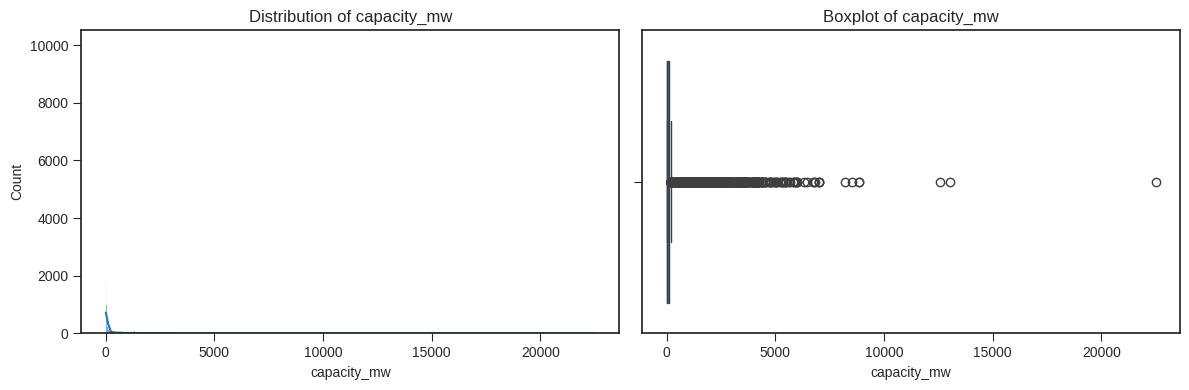

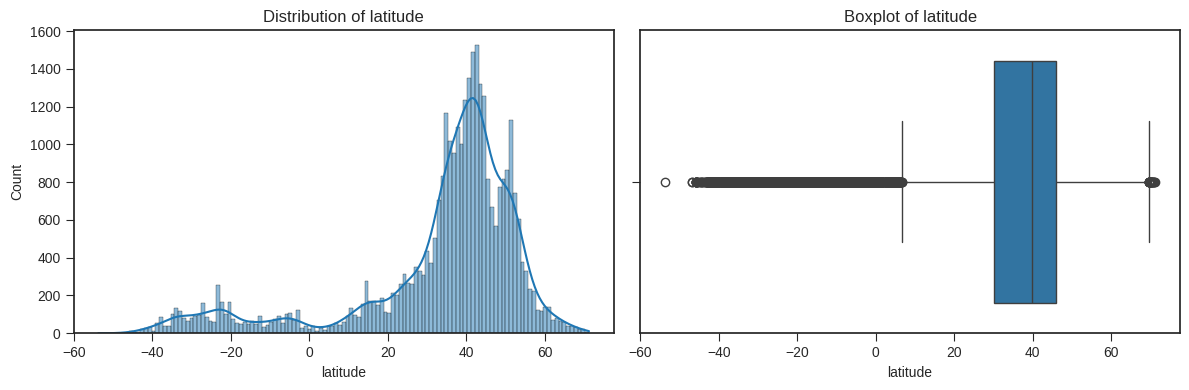

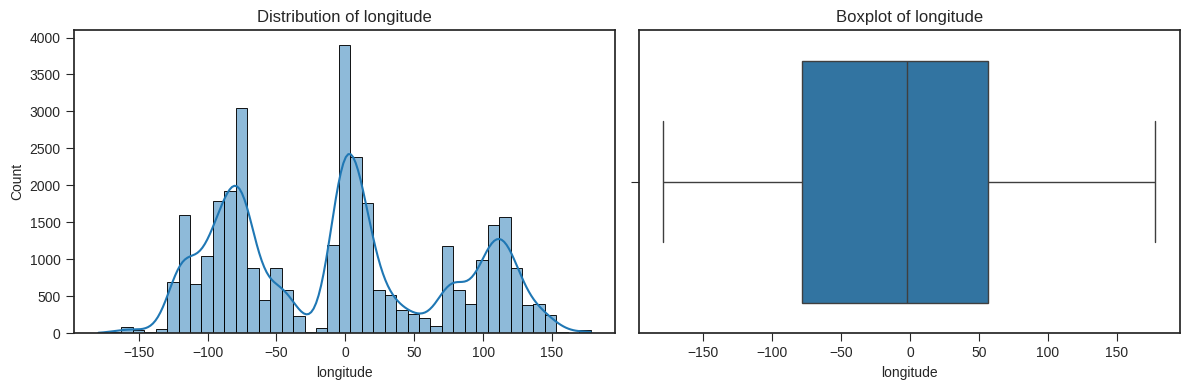

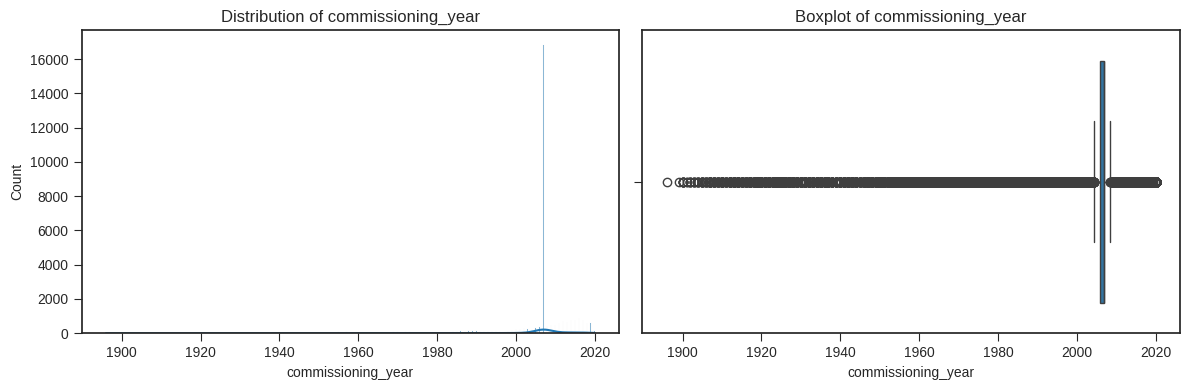

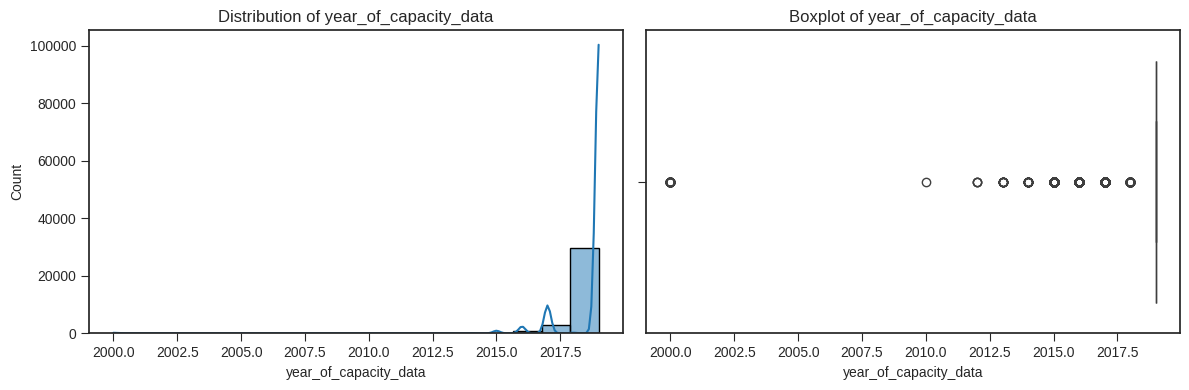

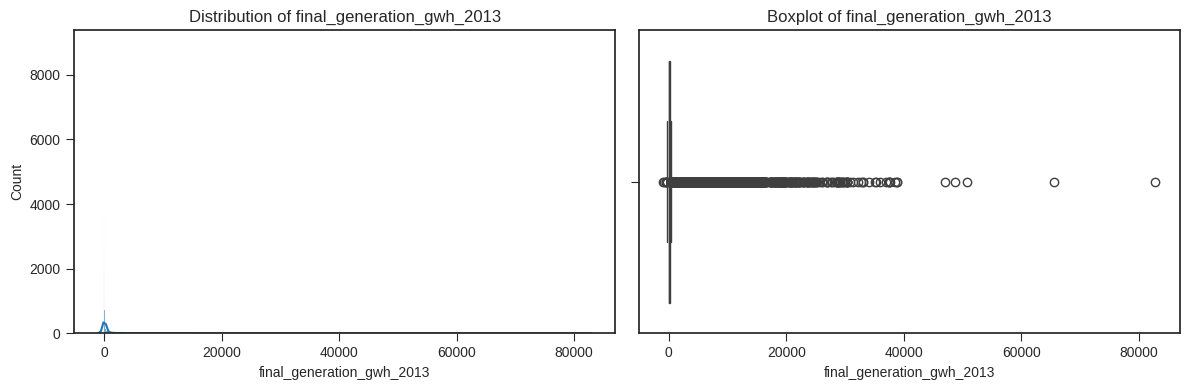

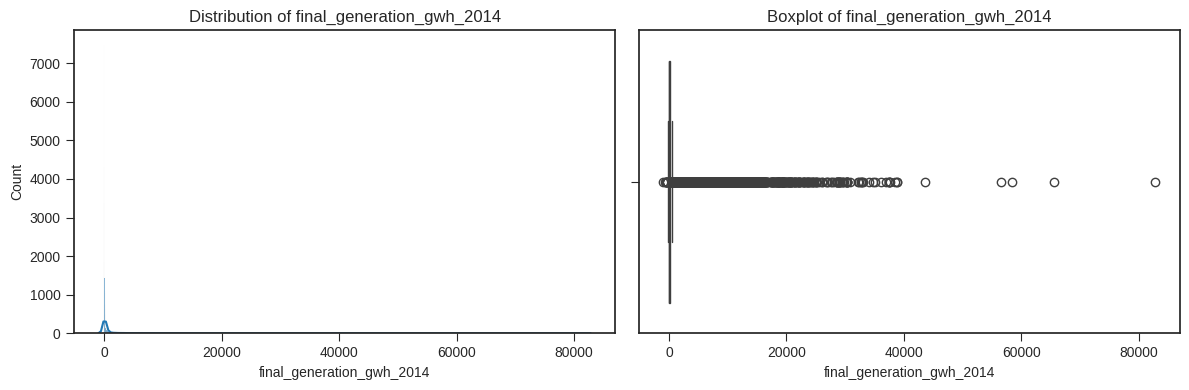

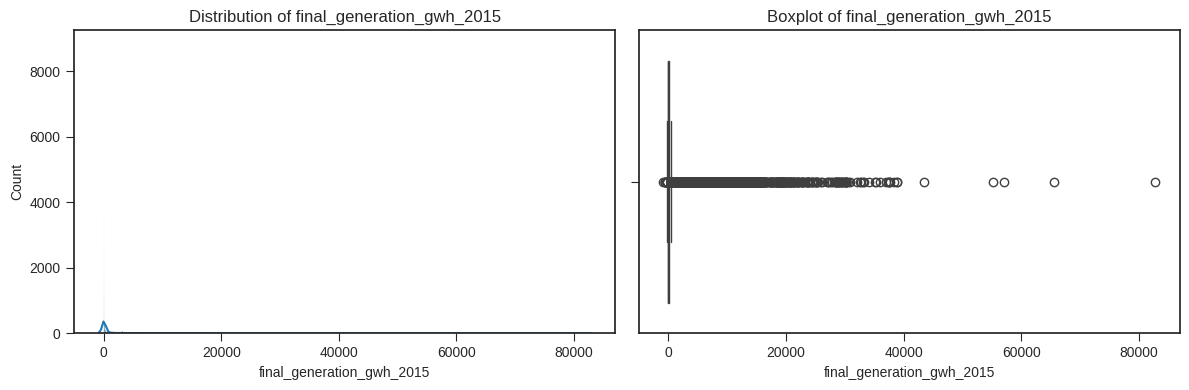

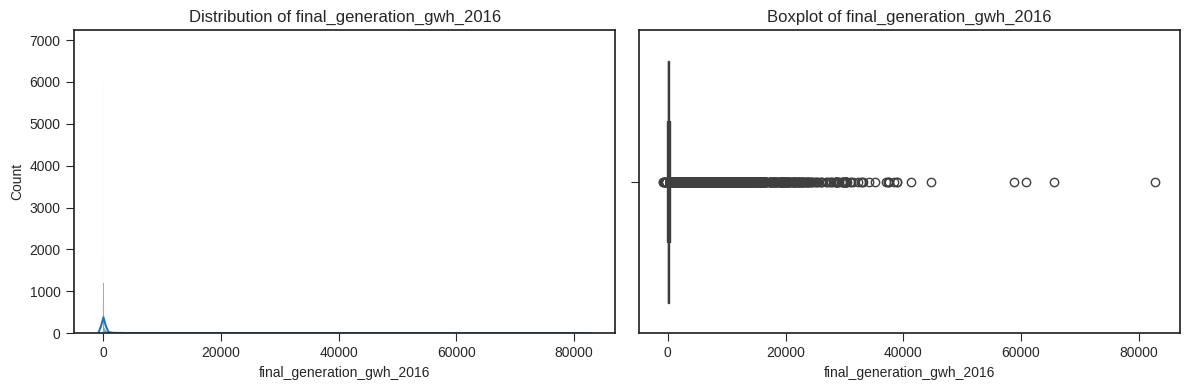

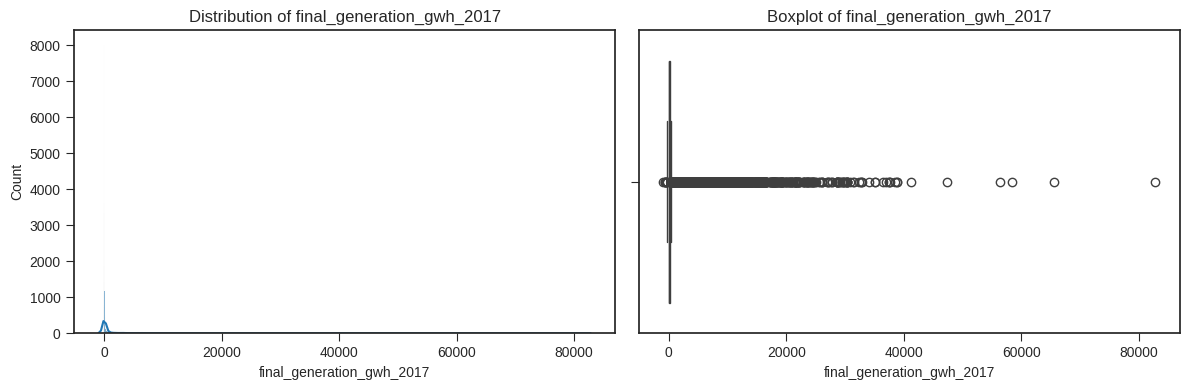

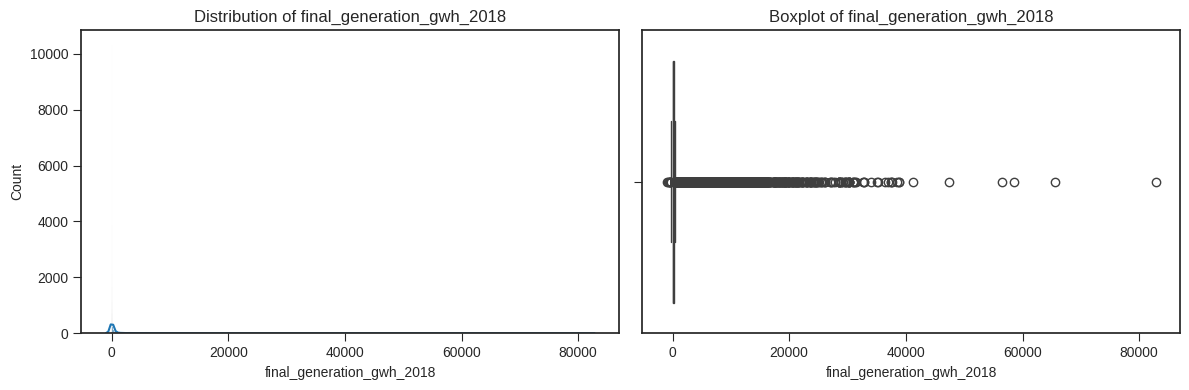

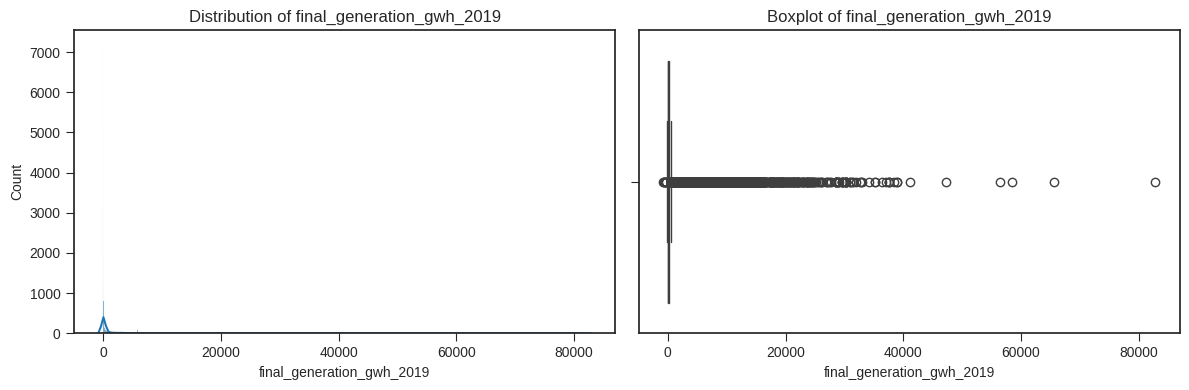

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-ticks")

for col in numerical_columns:
    plt.figure(figsize=(12,4))

    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

    # Boxplot for outliers
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()


### Interpretation of Distribution and Boxplots

#### Capacity
For the capacity field, the distribution plot shows that the capacity of the plants, is extremely right-skewed, this shows that most power plants operate at relatively smaller capacities compared to a few very large plants. The boxplot for capacity also supports this point, as it can be seen that the interquartile range is extremely small, along with that fact that most points appear after the right whisker, with a select few being much further away.

#### Latitude and Longitude
For the latitude and the longitude plots, the distribution for the latitude shows that a large portion of the plants exist betwenen 20 degrees and 40 degrees north of the equator, which corresponds with regions like the united states, europe and parts of asia. The boxplot show numerous values outside the whiskers, but these represent regions that are far north and south, mostly south. For the longitude, its distribution shows three peaks arounn -100 degrees, 0 degrees and 100 degrees. These regions correspond with the united states, the united kingdom & france and other nearby countries, china and nearby east asiain countries. The boxplot shows that there are no major outliers for the longitude, meaning the values are well spread out.
Coordinate Guide Website: https://blog.batchgeo.com/cities-by-latitude-and-longitude/


#### Commissioning Year
For the commissioning year distribution, it can be seen that although some power plants were commissioned in the 1900s, the vast majority of them were commissioned after 2000, within the last two decades. This could also be because older facilities have been shutdown and are no longer in consideration. The boxplot supports this train of thought, as it can be seen that most of the outliers occur towards the earlier years away from the interquartile range of the early 2000s.


#### Year of Capacity data (year data was collected or provided)

For this field, the distribution and boxplot shows that most of the data was collected starting from 2017, although the boxplot also shows that there have been earlier activities to collect data.


#### Electricity Generated Yearly (Final generation fields)

For all the final electricity generation fields (from 2013 to 2019), the distribution plots show a pattern similar to what is observed in the capacity variable. This indicates that most power plants generate relatively low amounts of electricity each year, while a smaller number of very large plants produce significantly more. The boxplots support this observation. The interquartile range is very narrow, showing that the majority of plants generate relatively smaller amounts of electricity. However, a large number of points extend far beyond the upper whisker, and several very extreme values appear far to the right. These represent major power stations that produce a much higher generation output compared to most plants.Because these high-generation plants are actual data points and represent real facilities, they should not be removed as outliers. They carry important information about global energy production patterns, and excluding them would damage the analysis by ignoring the largest contributors to the electricity supply.

In [ ]:
import numpy as np

outlier_summary = {}

for col in numerical_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr

    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary[col] = outlier_count

outlier_summary


{'capacity_mw': 5453,
 'latitude': 3721,
 'longitude': 0,
 'commissioning_year': 15407,
 'year_of_capacity_data': 3939,
 'final_generation_gwh_2013': 5757,
 'final_generation_gwh_2014': 5780,
 'final_generation_gwh_2015': 5807,
 'final_generation_gwh_2016': 5800,
 'final_generation_gwh_2017': 5806,
 'final_generation_gwh_2018': 5767,
 'final_generation_gwh_2019': 5757}

### Handling outliers

For this report, outliers will not be handled, as they signify power plants with exceptional capabilities. Changing any of these values will essentially harm the usability and integrity of the dataset. Therefore, no outlier removal was performed. Instead, outliers have been identified for exploratory purposes but retained to preserve the integrity and usability of the dataset.

### Additional Charts

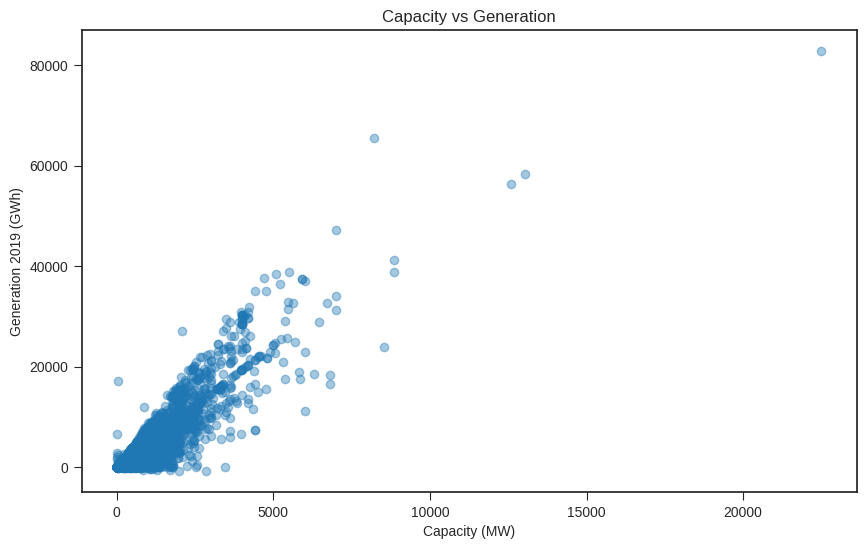

In [ ]:
# Scatterplots: Capacity vs Generation

plt.figure(figsize=(10,6))
plt.scatter(df["capacity_mw"], df["final_generation_gwh_2019"], alpha=0.4)
plt.xlabel("Capacity (MW)")
plt.ylabel("Generation 2019 (GWh)")
plt.title("Capacity vs Generation")
plt.show()


#### Capacity vs Electricity Generation (2019)
The scatter plot above shows a strong correlation between capacity and the amount of electricity generated. The higher the capacity, the higher the amount generated for that year.

This helps us answer our second question. We can see that there is a positive correlation between the capacity of a power plant and the amount of electricity it generates. This means that plants with higher capacities generally generate more electricity. However, this is not a perfect relationship, as there are plants with high capacities still generating low amounts of electricity. This means that there are other factors affecting the electrical output of power plants beyond just their capacity.

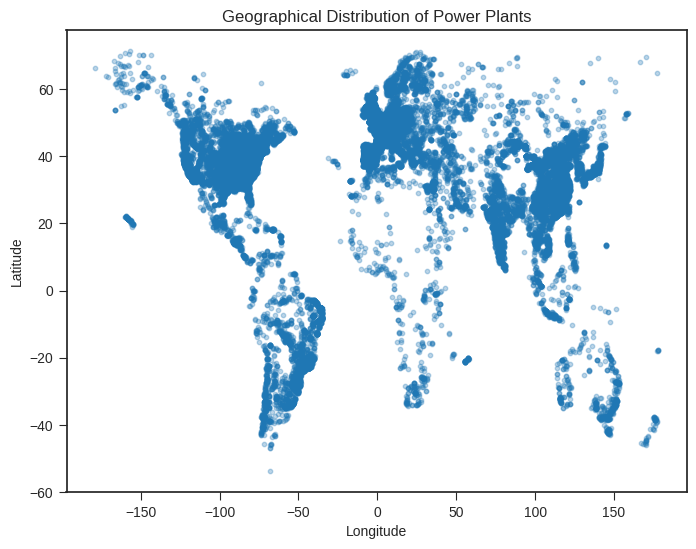

In [ ]:
# Scatterplot: Location of plants

plt.figure(figsize=(8,6))
plt.scatter(df["longitude"], df["latitude"], s=10, alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Power Plants")
plt.show()


#### Longitude and Latitude plot

From the scatter plot of the longitude and latitude, above, it can be seen that the dataset truly covers power plants globally, as the shape of the plot roughly resembles a world map. It can also be seen that a vast majority of plants exist in North America, Europe and East Asia, with plants being sparse in places like Africa and Australia. However, this could be due to reporting and data gathering factors.

We can also go a step further and plot a scatterplot with color grading to see how plant capacities differ from region to region.

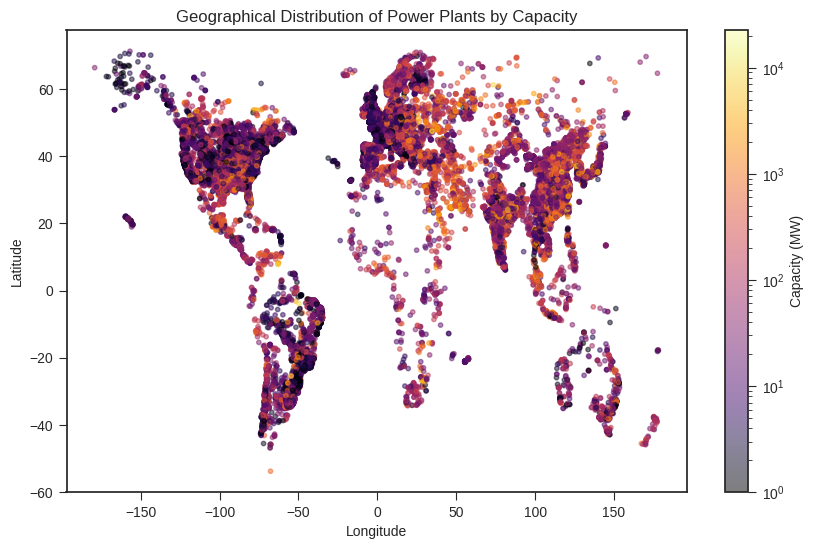

In [ ]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(10, 6))

scatter = plt.scatter(df["longitude"], df["latitude"], c=df["capacity_mw"], s=10, alpha=0.5, cmap="inferno", norm=LogNorm())

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Power Plants by Capacity")

colorbar = plt.colorbar(scatter)
colorbar.set_label("Capacity (MW)")

plt.show()

Here, we can see that high capacity power plants are scattered all around the world, but are especially concentrated in Europian and Asian regions. With this, we have a better understanding in order to try and understand our third question.

Yes, there is a pattern showing power plants with varying levels of capacities and clustering around the world, with some regions having fewer plants and some having many plants with lower capacities. However, we should also keep in mind, this could be due to a bias in the data gathering process.

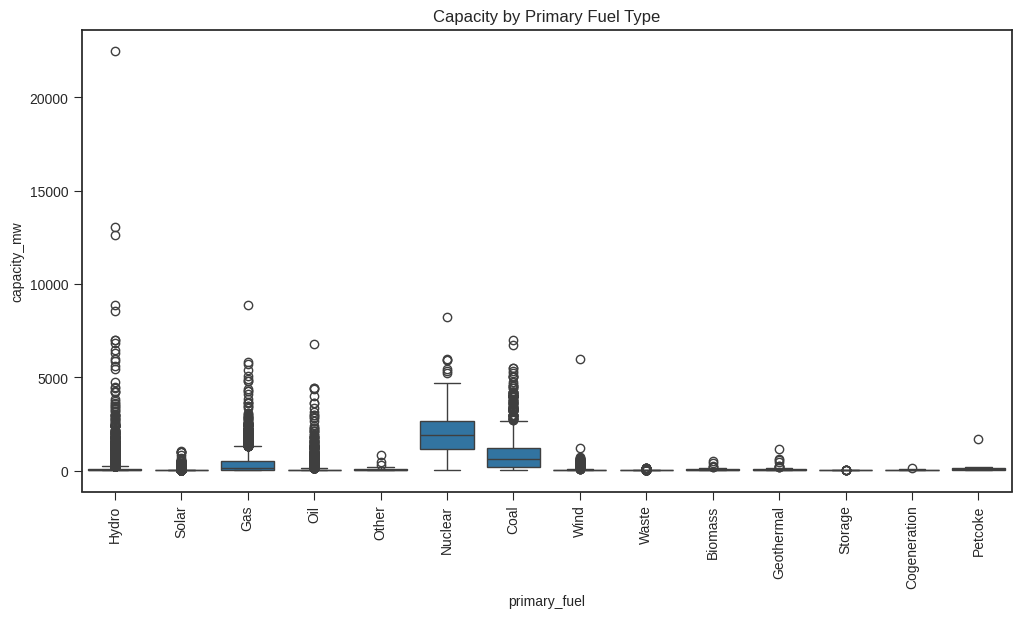

In [ ]:
# Boxplot: Capacity by fuel type

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="primary_fuel", y="capacity_mw")
plt.xticks(rotation=90)
plt.title("Capacity by Primary Fuel Type")
plt.show()


#### Capacity by fuel type

Finally, this plot helps us directly answer our very first question. For the primary fuel type boxplot, the distribution of the values for the plants' capacity across fuels shows clear differences in how large power plants are, depending on the energy source. Nuclear and coal plants have the highest capacities overall, this can be seen in their relatively high medians and very large outliers.

Hydro-powered plants also show a wide range of values, ranging from small to extremely large facilities. On the other hand, solar, wind, biomass, geothermal, storage, waste and cogeneration plants have much lower capacities in comparison. Their boxplots are much narrower towards the lower end, showing that these technologies are used in smaller scales.

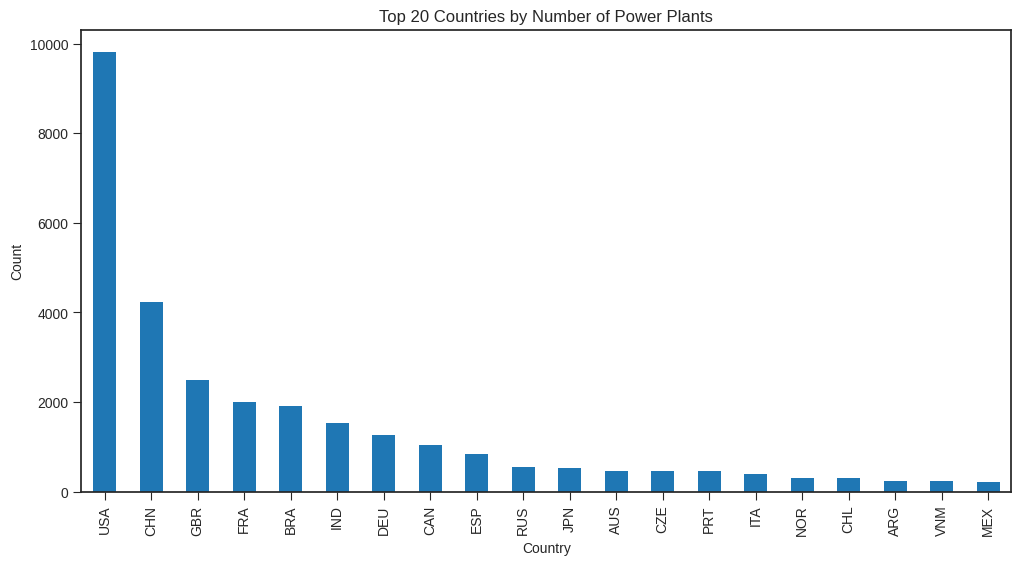

In [ ]:
# Distribution: COUNTRY

plt.figure(figsize=(12,6))
df["country"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 Countries by Number of Power Plants")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()


#### COUNTRIES WITH HIGHEST AMOUNTS OF POWER PLANTS

The barchart above shows how the countries (the first 20), with the highest amounts of power plants. The chart includes the United States, China, the United Kingdom, France, etc. This correlates with earlier observations from the longitude and latitude scatter plot

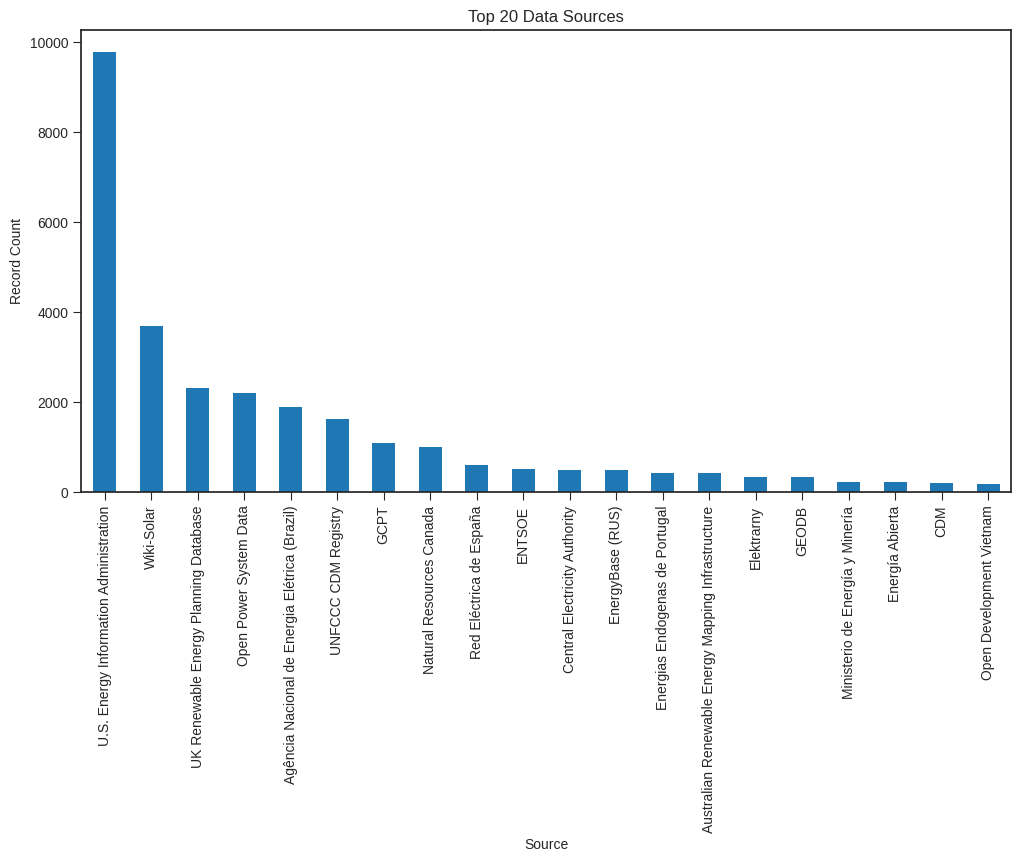

In [ ]:
# Distribution: SOURCE

plt.figure(figsize=(12,6))
df["source"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 Data Sources")
plt.xlabel("Source")
plt.ylabel("Record Count")
plt.xticks(rotation=90)
plt.show()


#### MAJOR SOURCES FOR DATA GATHERING

This plot simply shows that most of the data within this dataset was gotten from the United States Energy Information Administration, second to Wiki-Solar and the UK Renewable Energy Planning Database

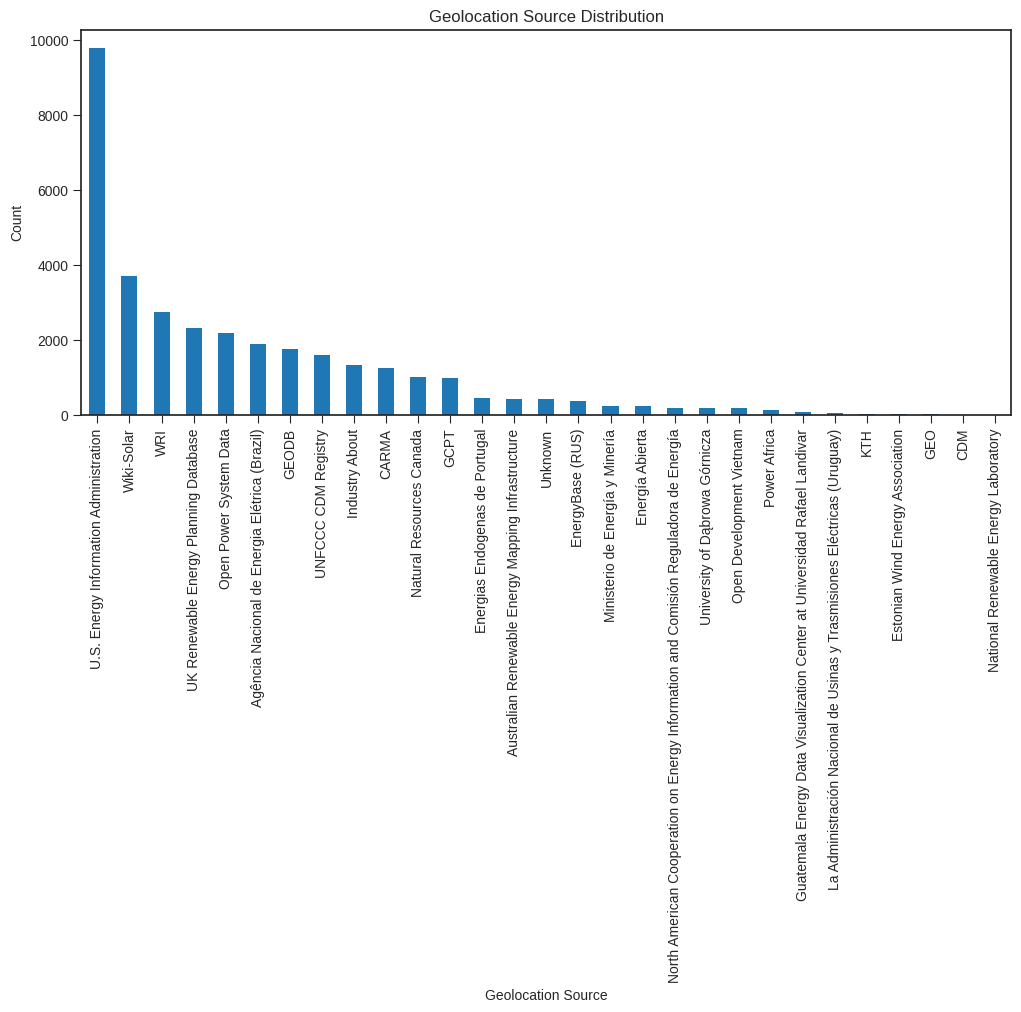

In [ ]:
# Distribution: GEOLOCATION SOURCE

plt.figure(figsize=(12,5))
df["geolocation_source"].value_counts().plot(kind="bar")
plt.title("Geolocation Source Distribution")
plt.xlabel("Geolocation Source")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()


#### Major Sources For Location Based Data

This plot simply shows that most of the location data was gotten from the United States Energy Information Administration, second to Wiki-Solar, WRI and the UK Renewable Energy Planning Database.

Based on the sources of the data, we could assume that there could have been greater efforts in recording power plants based in the US and UK, as most the data sources come from bodies or organizations based in those regions.

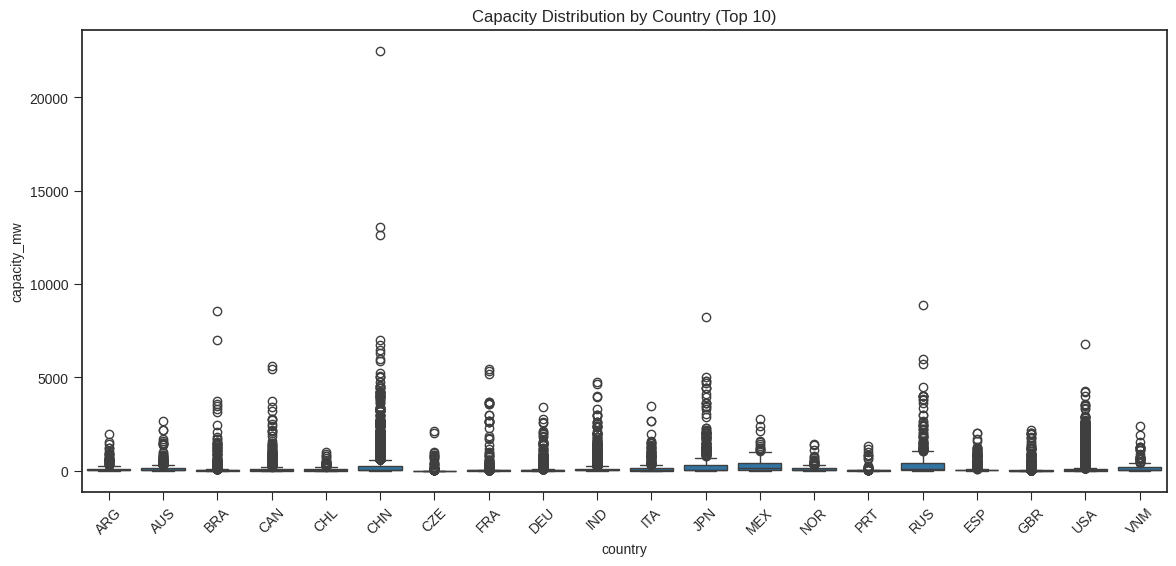

In [ ]:
# Capacity by Country

top_countries = df["country"].value_counts().head(20).index
plt.figure(figsize=(14,6))
sns.boxplot(data=df[df["country"].isin(top_countries)], x="country", y="capacity_mw")
plt.title("Capacity Distribution by Country (Top 10)")
plt.xticks(rotation=45)
plt.show()


#### Capacity Distribution by Country

The plot above shows how the capacity of power plants across different countries vary from one another. It shows that countries like China, Russia, USA, etc, tend to have power plants with relatively higher capacities.

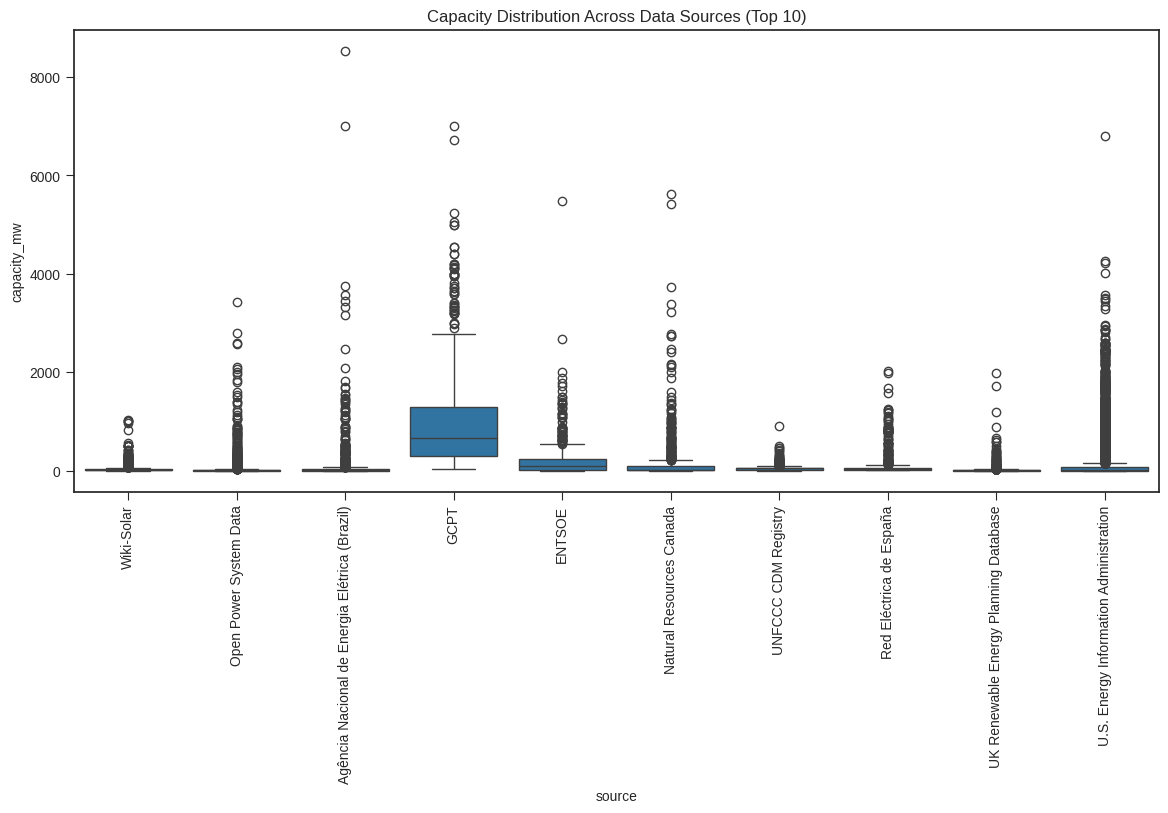

In [ ]:
# Capacity by Source

plt.figure(figsize=(14,6))
top_sources = df["source"].value_counts().head(10).index
sns.boxplot(data=df[df["source"].isin(top_sources)], x="source", y="capacity_mw")
plt.xticks(rotation=90)
plt.title("Capacity Distribution Across Data Sources (Top 10)")
plt.show()


#### Capacity across data sources

The plot above shows that certain data sources like GCPT and ENTSOE, tend to provide data for higher capacity plants, over lower capacity power plants. While Wiki-Solar shows signs of the opposite. This could signify a bias in data collection on the part of these various data collection bodies.

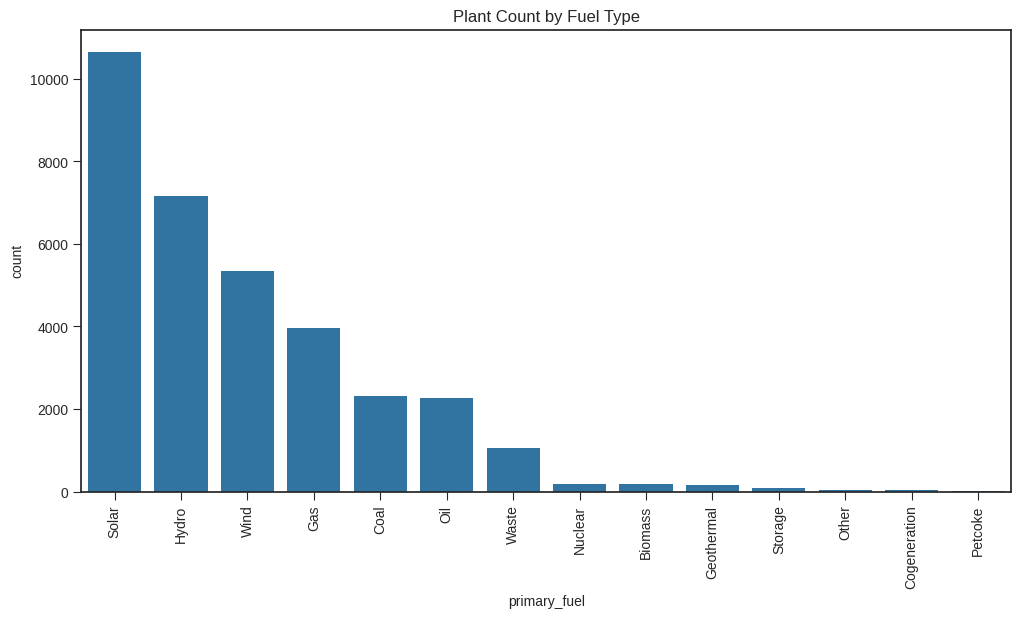

In [ ]:
# Plant Count Split by Fuel Type and Country

plt.figure(figsize=(12,6))
sns.countplot(data=df, x="primary_fuel", order=df["primary_fuel"].value_counts().index)
plt.xticks(rotation=90)
plt.title("Plant Count by Fuel Type")
plt.show()


#### Power Plant count by Fuel type

The plot above shows the most reccurring fuel types across all the power plants. It can be seen that Solar energy, despite having lower capacity overall (based on the Capacity by fuel type plot), seems to be the most popular. This may be due factors like cost of building and maintenance, as well as abundance of fuel/fuel source. This observation is supported by the fact that the next two fuel types are also renewable enery types, which cannot be depleted. This may also be due to the fact that the world has begun shifting towards cleaner energy sources.

# 6. CONCLUSION

This project carried out data cleaning, wrangling and exploratory data analysis on the Global Power Plant Dataset. The dataset contains information on power plants from different parts of the world, including their locations, fuel types, capacities, commissioning years and annual electricity generation. However, before any useful analysis could be carried out, several issues within the dataset had to be addressed.

The first stage involved inspecting the data and identifying columns with missing values, redundant information and unsuitable data types. Columns with little analytical value or very high amounts of missing data were removed, while the remaining missing values were handled depending on the type of information contained in each column. The actual and estimated yearly generation values were also combined, with actual values being used first and estimated values filling the gaps where necessary. This helped create a cleaner dataset that could be used for further analysis.

After preparing the data, several patterns became clearer. Most power plants in the dataset have relatively low or moderate capacities, while a much smaller number of plants have extremely high capacities. This shows that the distribution of power plant capacity is heavily uneven, with a few very large plants standing out from the majority.

The type of fuel used also appears to be related to the capacity of a power plant. Nuclear and coal plants generally had higher capacities, while solar, wind, biomass, geothermal, storage, waste and cogeneration plants were mostly concentrated at lower capacities. Hydro plants showed a much wider range, with both small and very large facilities appearing in the dataset. This shows that different energy technologies are commonly built and operated at different scales.

The relationship between capacity and electricity generation was also examined. The scatterplot showed that plants with higher capacities generally produce more electricity. However, some high-capacity plants still recorded relatively low generation values. This means that capacity is an important factor, but it is not the only factor that affects the actual amount of electricity generated.

The geographical plots showed that power plants are distributed across different parts of the world, with larger clusters appearing in North America, Europe and Asia. High-capacity plants were also found across several regions rather than being limited to one country or continent. However, some areas, particularly parts of Africa and South America, appeared to have fewer recorded plants. This may reflect actual differences in infrastructure, but it may also be influenced by how the data was gathered and reported.

This possibility became more noticeable when the data sources were examined. A large portion of the records came from organisations such as the U.S. Energy Information Administration, Wiki-Solar and the UK Renewable Energy Planning Database. Some sources also appeared to contain more high-capacity plants than others. Therefore, the patterns observed in the dataset may be influenced by both real differences in global power infrastructure and differences in the type or amount of data collected by each source.

Overall, the analysis showed that power plants vary greatly depending on their fuel type, location and installed capacity. It also showed that having a large number of plants does not necessarily mean having the largest overall capacity, since many smaller plants may contribute less than a smaller number of very large plants. The project demonstrates how a large and incomplete dataset can be cleaned and explored in order to produce a clearer understanding of global power generation infrastructure.

Further analysis could build on this by comparing total capacity across countries, separating renewable and non-renewable energy sources, examining changes in power plant construction over time, or developing a model to estimate electricity generation based on capacity, fuel type, age and location.